In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from structuralvar import Clean, SVAR_KL

data = pd.read_excel('data/structural_shocks.xlsx').set_index('Unnamed: 0').rename_axis(None, axis = 0)
sd_df = pd.read_excel('data/sd.xlsx').set_index('Unnamed: 0').rename_axis(None, axis = 0).set_axis(['s1d0', 's0d0'])
data = data.loc[:, data.columns[71:]].copy()
data.loc['s1d0', :] = sd_df.iloc[0, :-1].to_numpy()
data.loc['s0d0', :] = sd_df.iloc[1, :-1].to_numpy()
data = data.set_axis(pd.DatetimeIndex(data.columns), axis=1)


In [6]:
data.loc['s1d1'] = 1 - data.loc['s1d0'].copy()
data.loc['s0d1'] = 1 - data.loc['s0d0'].copy()

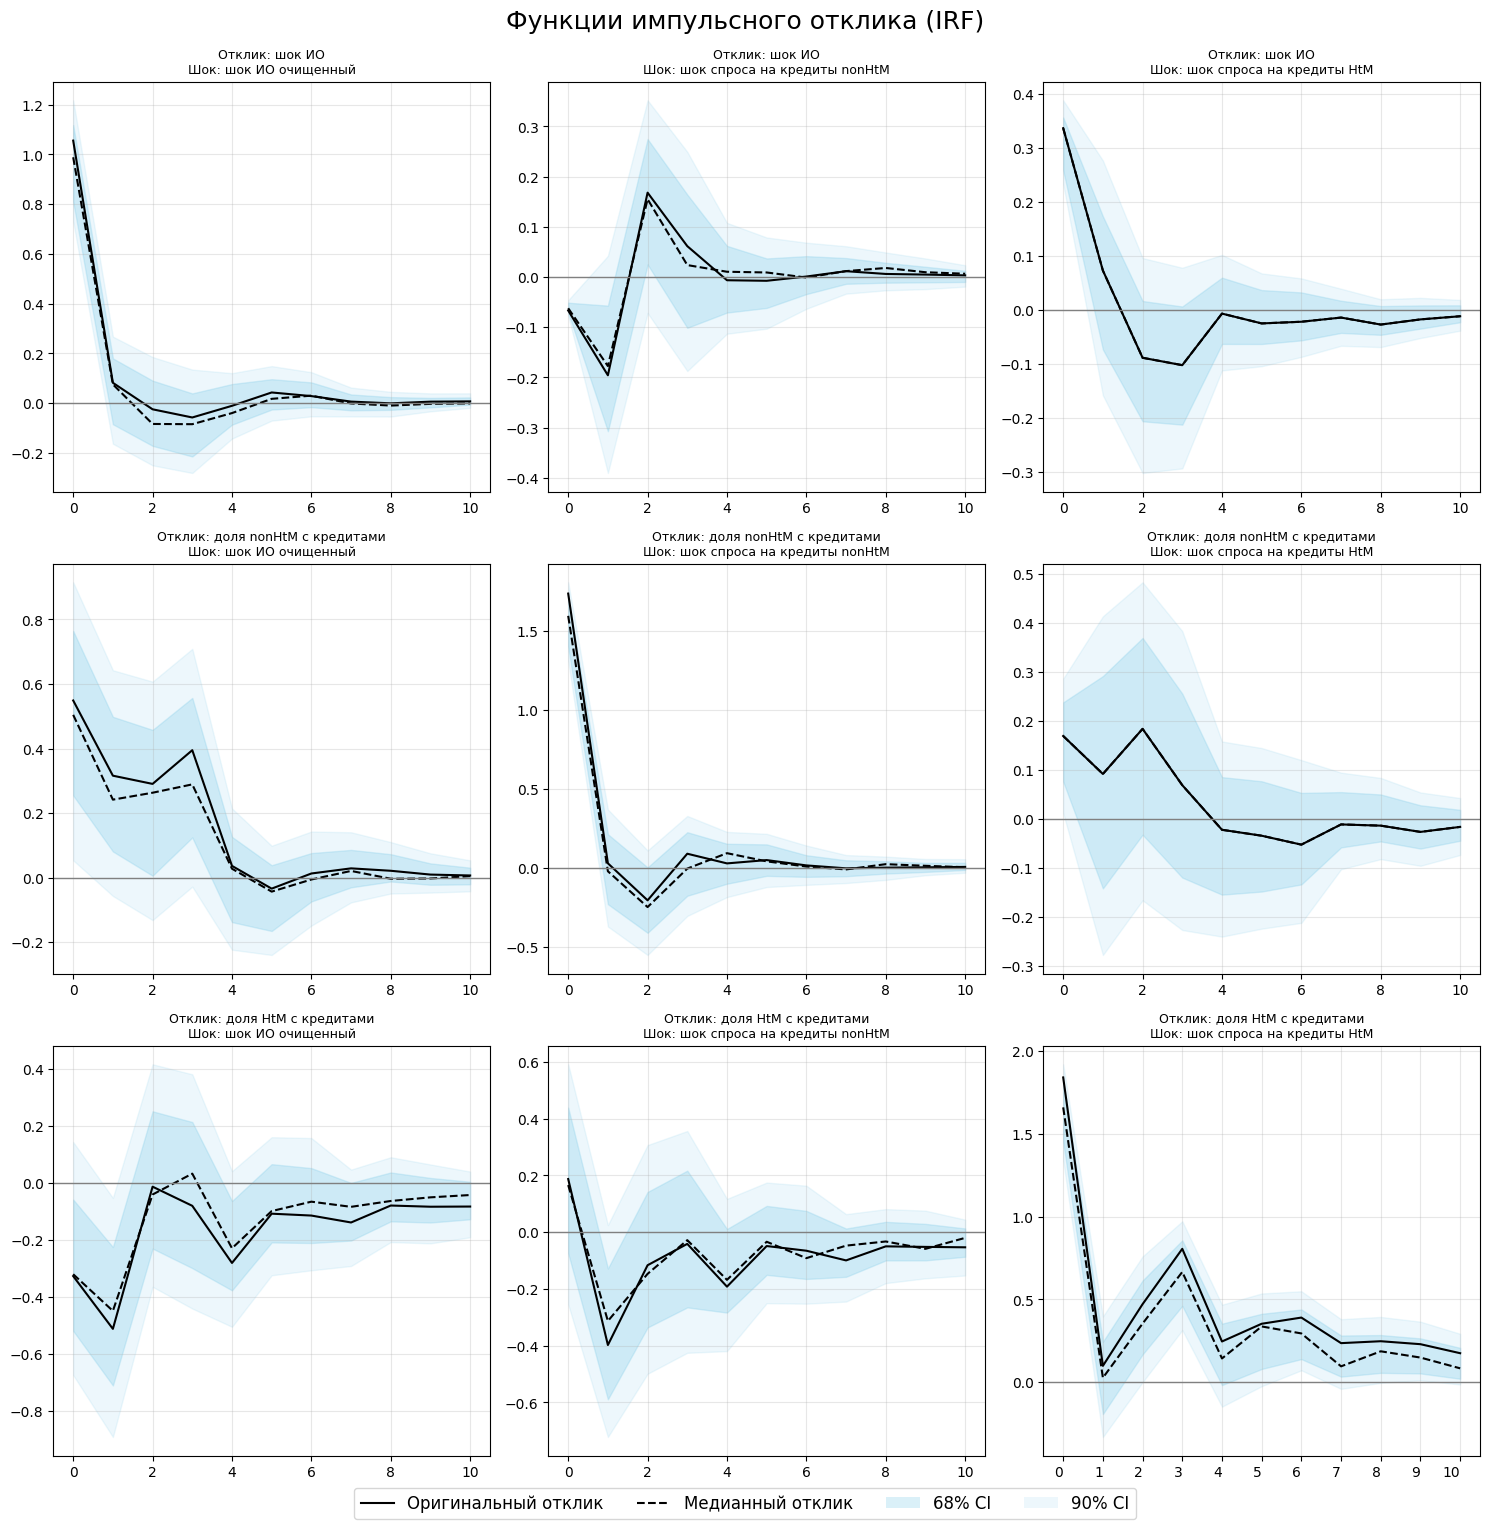

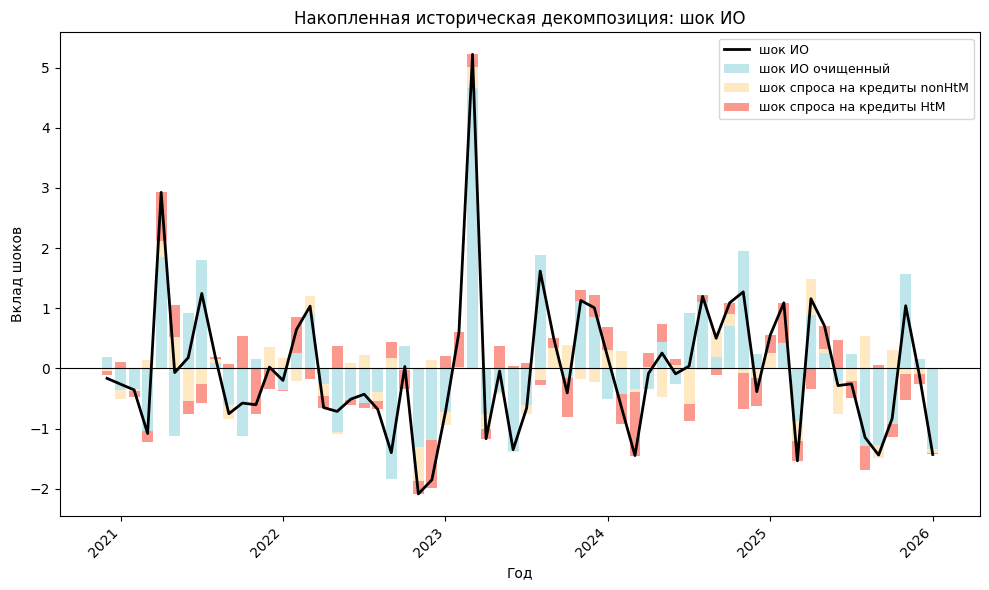

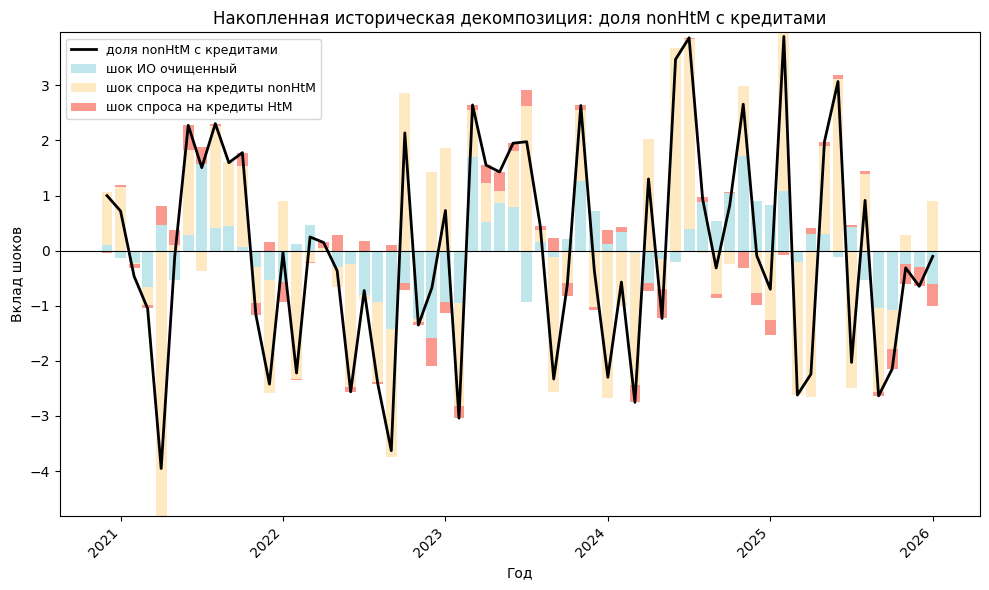

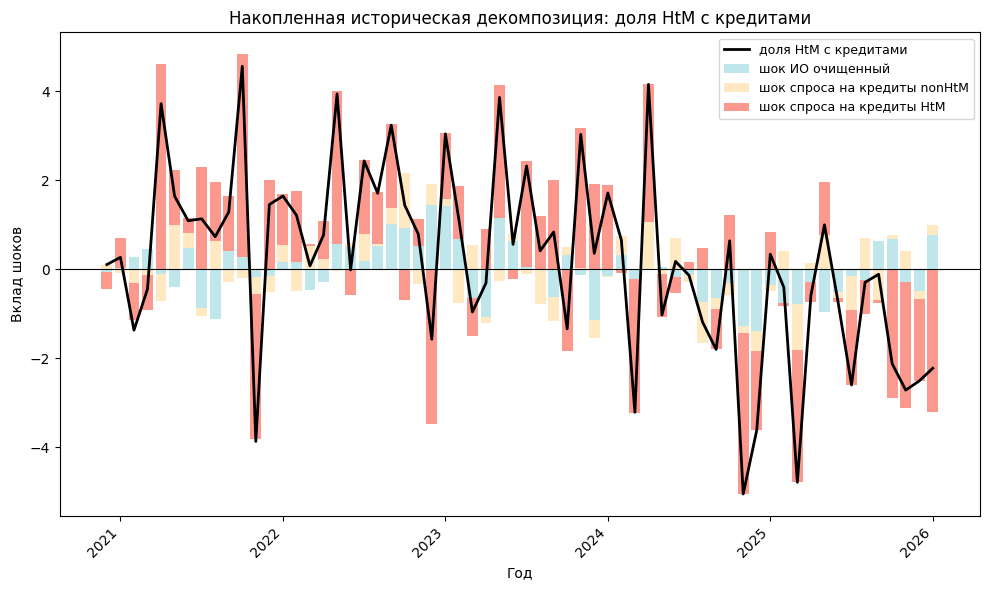

In [8]:
short_run_anchor = [

]
long_run_anchor = [
    (0, 0, 1, 10),
    (0, 0, 2, 10),
]
short_run_signs = [(0, 0, 0, True, 0, 1),
                   (0, 1, 1, True, 0, 1),
                   (0, 2, 2, True, 0, 1),

                   ]
long_run_signs = [
    
]

lag = 3

endog_names = ['pi_e', 's1d1', 's0d1']


df_endog = data.loc[endog_names, :]   # K×T

model = SVAR_KL(
    data=df_endog,
    p=lag,             #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок ИО очищенный', 'шок спроса на кредиты nonHtM', 'шок спроса на кредиты HtM'],
    y_dict = ['шок ИО', 'доля nonHtM c кредитами', 'доля HtM с кредитами']
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 12
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=10,
                     main_color='skyblue')
hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = True,
                                    const_clean = True)
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъяснено шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


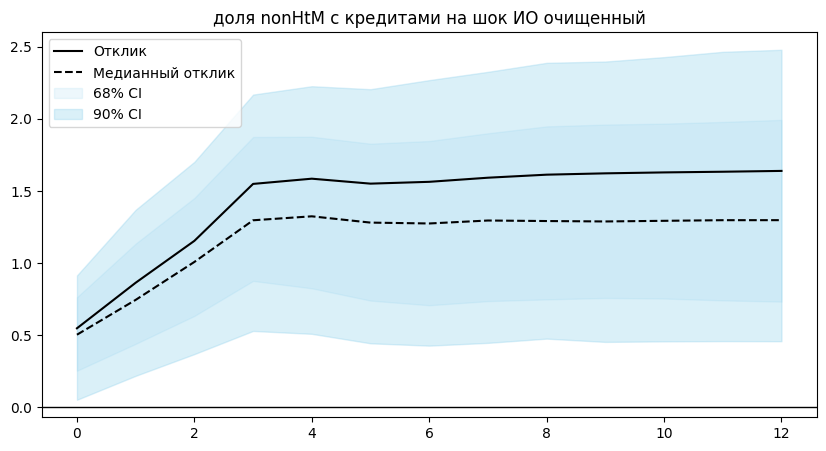

In [10]:
model.plot_single_irf(irf_sims,
                's1d1',
                'шок ИО очищенный',
                'skyblue',
                plot_simulations = False,
                horizon=20,
                cumm = True)

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


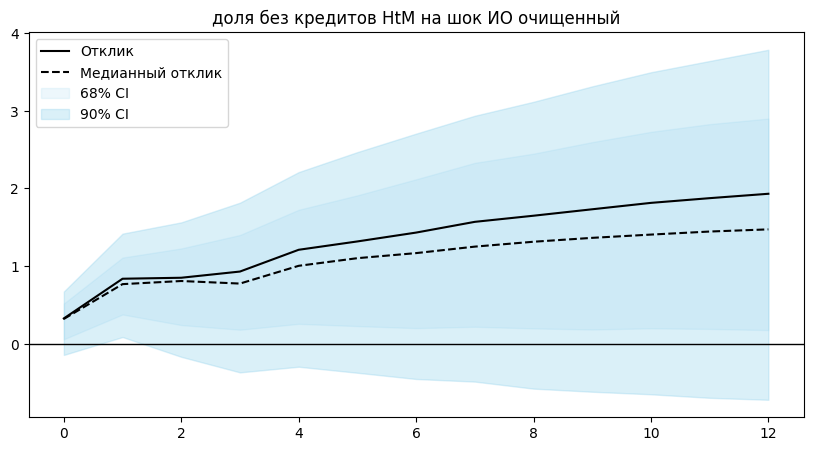

In [23]:
model.plot_single_irf(irf_sims,
                's0d0',
                'шок ИО очищенный',
                'skyblue',
                plot_simulations = False,
                horizon=20,
                cumm = True)

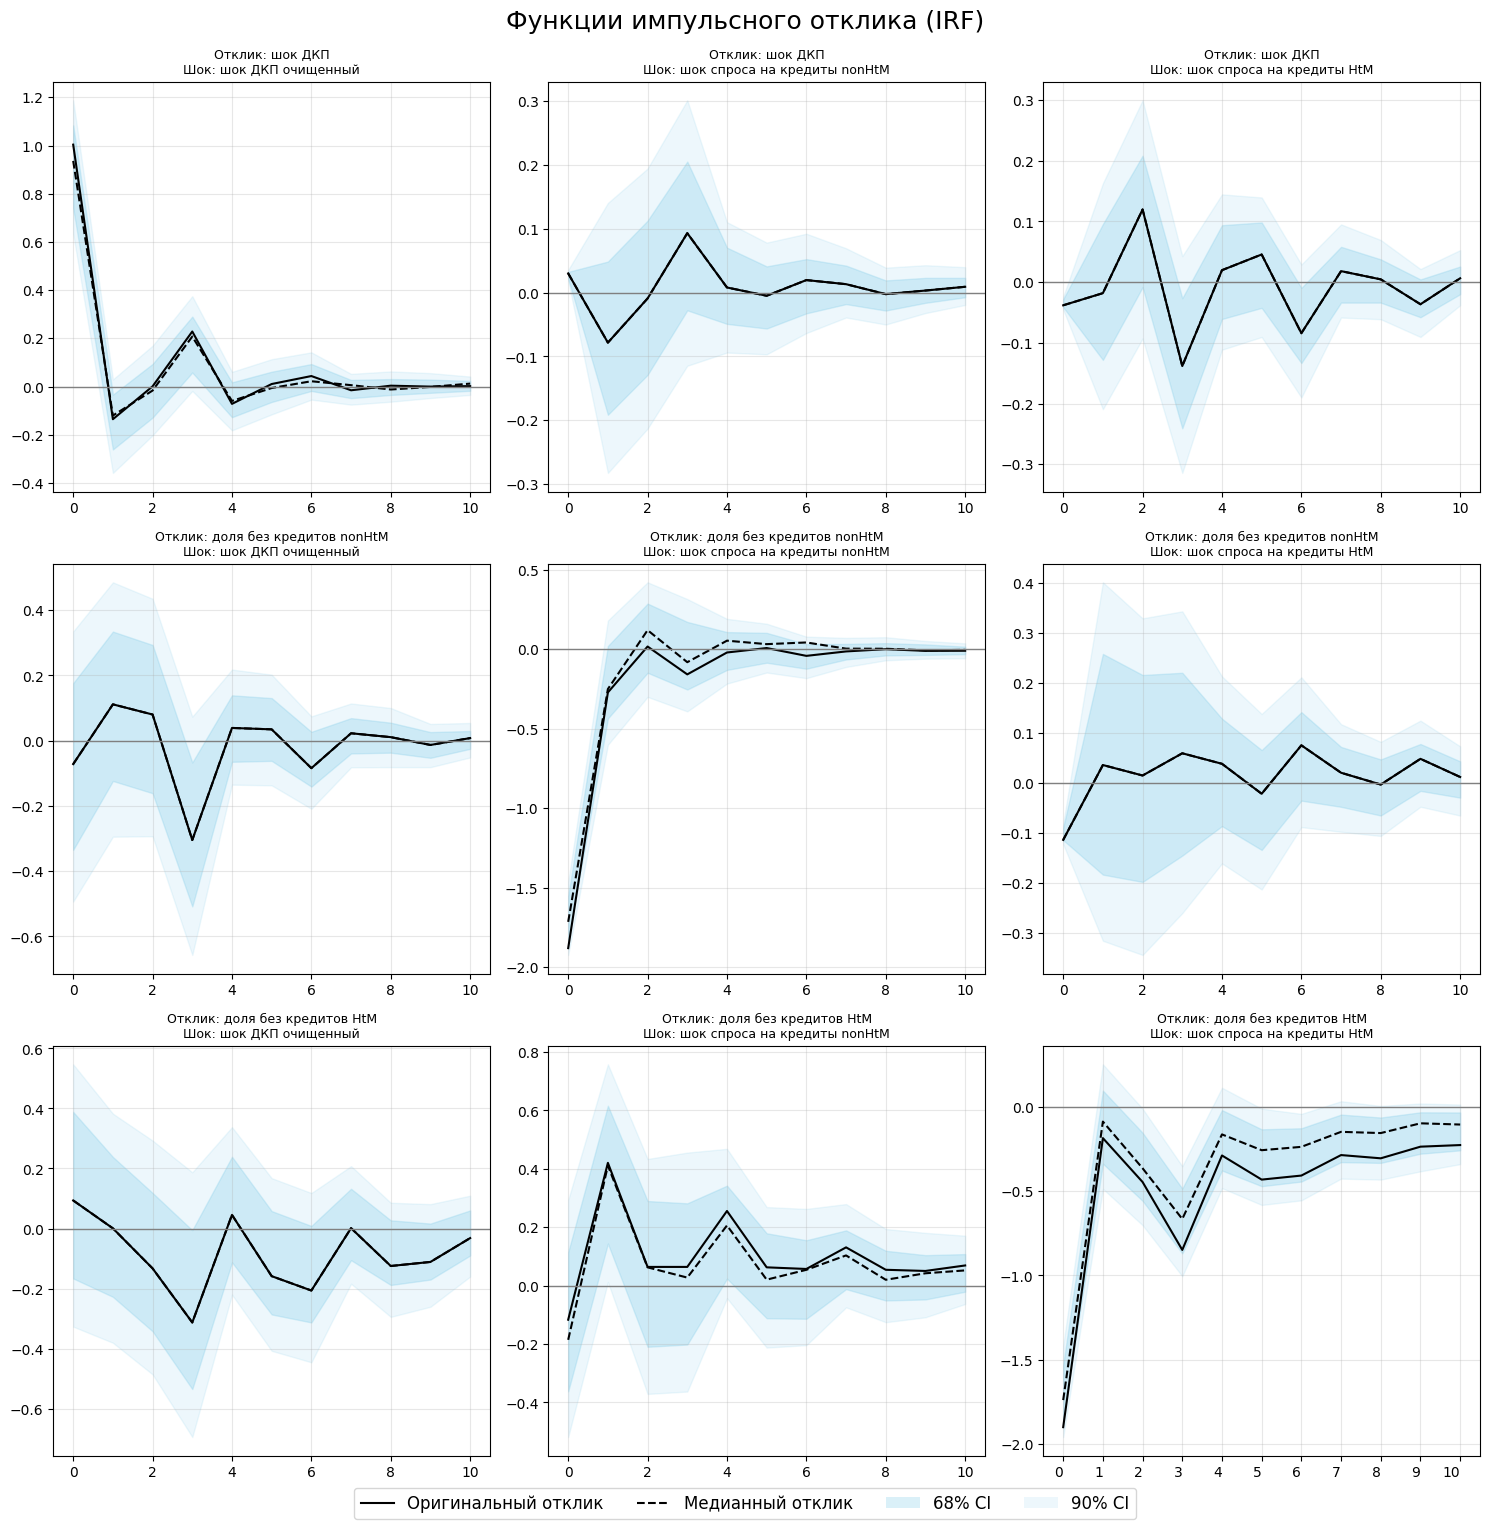

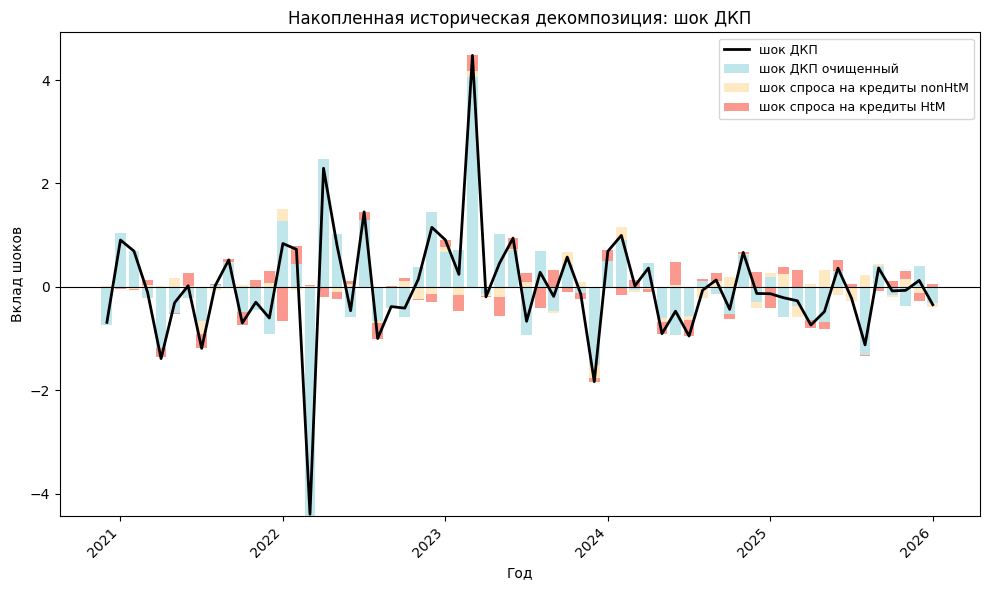

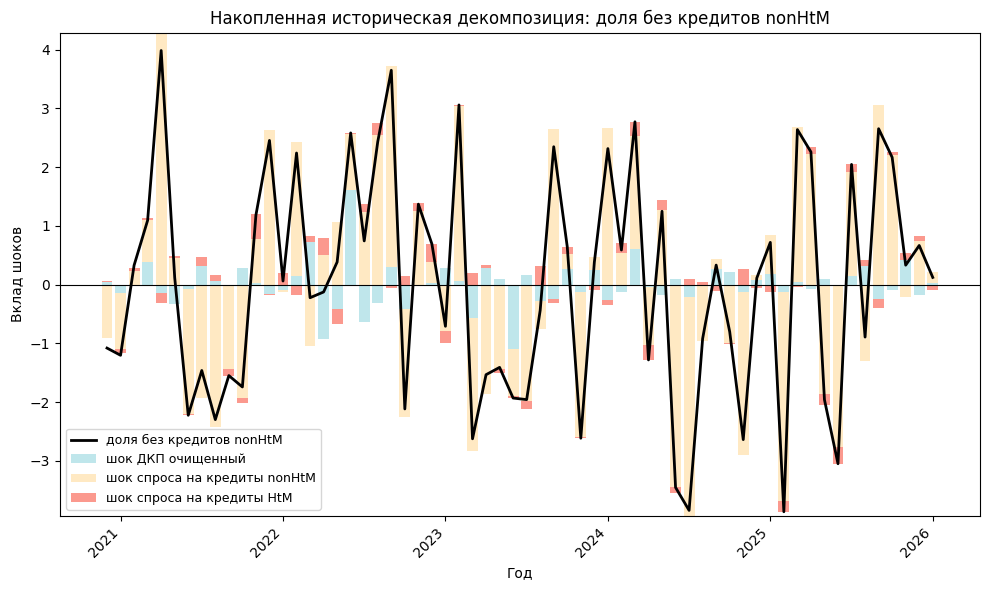

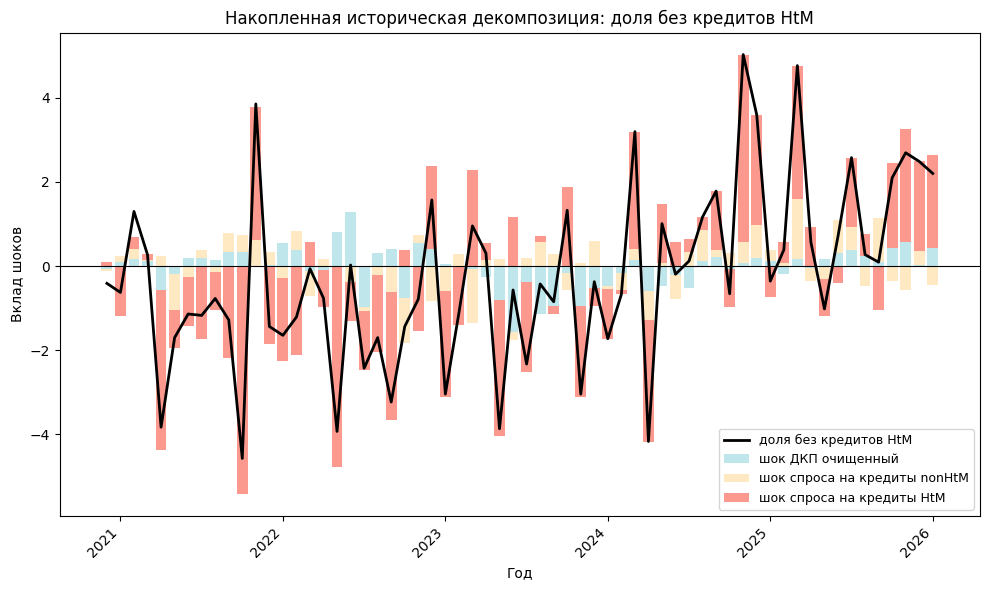

In [4]:
short_run_anchor = [
    #(0, 0, 2, 0, 1),
]
long_run_anchor = [
    #(0, 0, 0, 1)
]
short_run_signs = [(0, 0, 0, True, 0, 1),
                   (0, 1, 1, False, 0, 1),
                   (0, 2, 2, False, 0, 1),

                   ]
long_run_signs = [

]

lag = 3

endog_names = ['real_ruonia', 's1d0', 's0d0']


df_endog = data.loc[endog_names, :]   # K×T

model = SVAR_KL(
    data=df_endog,
    p=lag,             #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок ДКП очищенный', 'шок спроса на кредиты nonHtM', 'шок спроса на кредиты HtM'],
    y_dict = ['шок ДКП', 'доля без кредитов nonHtM', 'доля без кредитов HtM']
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 12
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=10,
                     main_color='skyblue')
hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = True,
                                    const_clean = True)
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъяснено шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]